# AG-HYPOPT · Trial 17

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Sixteen trials are registered; cell 2 reports `phase = trials` (16/5), so proposals carry expected-improvement (ei) values. **Best = trial_08** (objective 0.1099). Picture (mu travel = `lr_mu*(1 - mu_anneal/2)`):

- **trial_08 (0.1099, best):** travel 0.134.
- optimum cluster (0 div): trial_15 0.1103 (0.127), trial_16 0.1112 (0.128), trial_12 0.1115 (0.128), trial_09 0.1126 (0.123), trial_01 0.1127 (0.120), trial_14 0.1127 (0.140), trial_13 0.1132 (0.134).
- lower travel: trial_05 0.1135 (0.088), trial_07 0.1140 (0.097), trial_06 0.1188 (0.082), trial_11 0.1188 (0.159).
- diverging: trial_10 0.1975 (0.099), trial_03 0.1362 (0.074), trial_04 0.1418 (0.074), trial_02 0.1449 (0.264).

State of play: twelve divergence-free runs; the optimum is a flat plateau at travel ~0.13 (the best seven within 0.004, objectives 0.1099-0.1132) and no gamma-knob variation has beaten trial_08. Lower travel (0.082-0.097) is consistently a little worse (0.1135-0.1188) but mostly safe, except at ~0.074 where trials 03/04 diverged. Residual errors are everywhere the same: mid-T mu overshoot, 3nW high-T mu undershoot, low-T gamma under-recovery. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_17'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (16/5 trials)
ID |     ei | params
 1 | 3.7097 | {"gamma_anneal": 0.4765386839839501, "lr_gamma": 0.40019481336701157, "lr_mu": 0.10585880036608775, "mu_anneal": 0.348119618536484}
 2 | 0.5828 | {"gamma_anneal": 0.22863682241337535, "lr_gamma": 0.46174465124615904, "lr_mu": 0.1813001814666711, "mu_anneal": 0.5675398131484446}
 3 | 3.1486 | {"gamma_anneal": 0.5068455314093507, "lr_gamma": 0.20667610285007593, "lr_mu": 0.17650279500099222, "mu_anneal": 0.34297432524753163}
 4 | 2.5790 | {"gamma_anneal": 0.4606342754070931, "lr_gamma": 0.48854650957434875, "lr_mu": 0.12613396085056008, "mu_anneal": 0.3548115520017638}
 5 | 3.9312 | {"gamma_anneal": 0.4465210403682711, "lr_gamma": 0.4525128273581829, "lr_mu": 0.10670895762231856, "mu_anneal": 0.3507715189232054}
 6 | 3.7847 | {"gamma_anneal": 0.4610665420425466, "lr_gamma": 0.4540505345592434, "lr_mu": 0.09472300477391984, "mu_anneal": 0.31823013690357616}
 7 | 3.8088 | {"gamma_anneal": 0.5070677423857818, "lr_gamma": 0.429

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (16 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 5: **ei 3.93** — `lr_mu=0.107`, `mu_anneal=0.351` (travel **0.088**), `lr_gamma=0.453`, `gamma_anneal=0.447`.
- candidate 7: ei 3.81 — `lr_mu=0.094`, `mu_anneal=0.349` (travel 0.077), `lr_gamma=0.430`, `gamma_anneal=0.507`.
- candidate 8: ei 3.80 — `lr_mu=0.086`, `mu_anneal=0.357` (travel 0.071), `lr_gamma=0.463`, `gamma_anneal=0.429`.
- candidate 6: ei 3.78 — `lr_mu=0.095`, `mu_anneal=0.318` (travel 0.080), `lr_gamma=0.454`.
- candidate 1: ei 3.71 — `lr_mu=0.106`, `mu_anneal=0.348` (travel 0.087), `lr_gamma=0.400`.

All five top-ei candidates cluster in the low-travel region (0.071-0.088), so the surrogate is now pointing below the optimum. Candidate 5 is the maximum-ei point and sits at travel 0.088 — very close to trial_05 (0.088, objective 0.1135) with a similar, proven-safe gamma schedule (`lr_gamma=0.453` vs `0.465`). It is the safest of the low-travel candidates: candidates 7, 8 and 6 push toward 0.071-0.080, approaching the ~0.074 region where trials 03 and 04 diverged. Since the plateau is flat and the high-ei candidates are all in one neighbourhood, the maximum-ei candidate is the natural pick, and among that neighbourhood it is the one furthest from the known divergence band.

I choose candidate 5 (5 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 5            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.4465210403682711, 'lr_gamma': 0.4525128273581829, 'lr_mu': 0.10670895762231856, 'mu_anneal': 0.3507715189232054}
Running  1nW Trans05 ... 

μ 9.39 -> 10.43 | γ 8.5 -> -0.93 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 36.10 | γ 8.5 -> 5.97 | NLL 5.04


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 71.57 | γ 14.1 -> 14.38 | NLL 3.46


Running 3nW Trans100 ... 

μ 175.71 -> 104.30 | γ 14.1 -> 14.17 | NLL 3.25



Total: 7.6 min


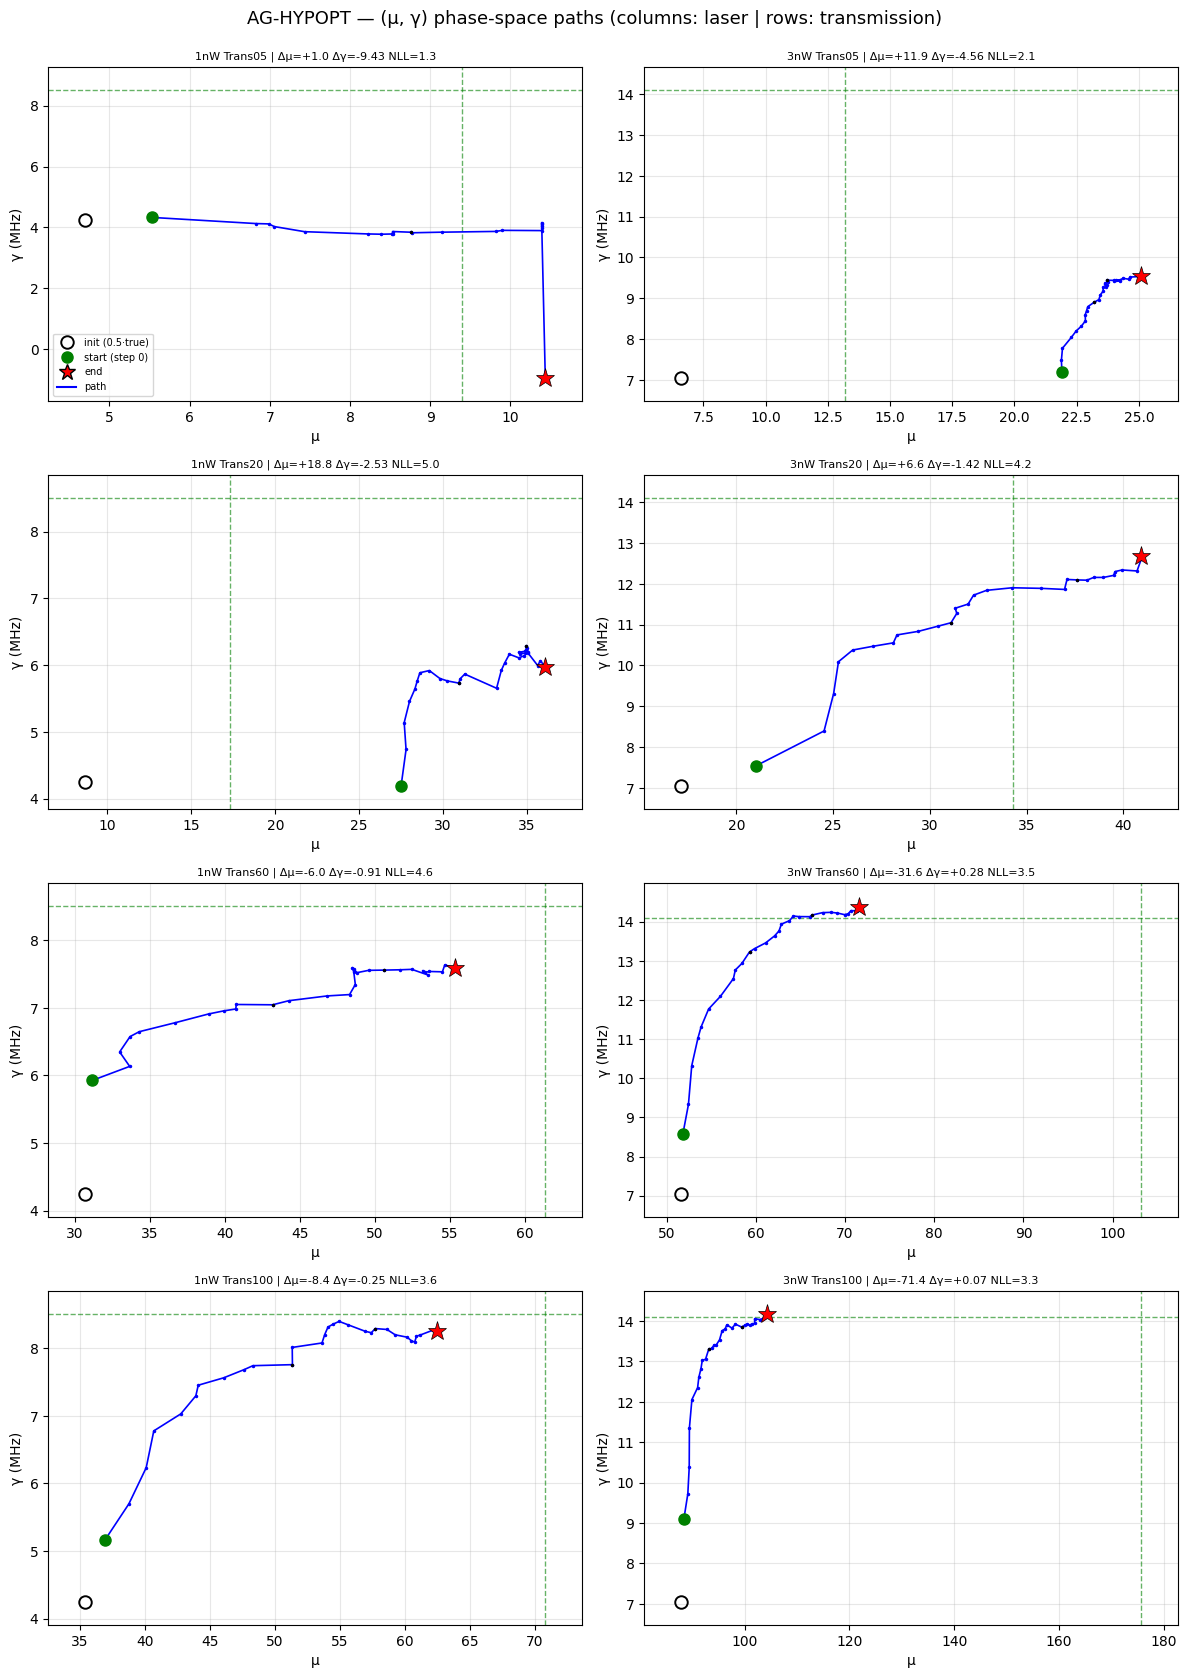

trial finished in 7.7 min
objective = 0.1329 ± 0.0915
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05 !D     9.39   10.43   +11.1 |     8.50   -0.93  -110.9
1nW Trans20       17.32   36.10  +108.5 |     8.50    5.97   -29.7
1nW Trans60       61.37   55.33    -9.8 |     8.50    7.59   -10.7
1nW Trans100       70.82   62.46   -11.8 |     8.50    8.25    -3.0
3nW Trans05       13.20   25.09   +90.1 |    14.10    9.54   -32.4
3nW Trans20       34.28   40.91   +19.3 |    14.10   12.68   -10.1
3nW Trans60      103.20   71.57   -30.6 |    14.10   14.38    +2.0
3nW Trans100      175.71  104.30   -40.6 |    14.10   14.17    +0.5

weighted objective (T-graded, cap=1.0) = 0.1329 | diverged cells: 1
μ: RMSE 29.036 (rel 53.8%, bias -9.888) | γ: RMSE 3.859 (rel 42.5%, bias -2.344)


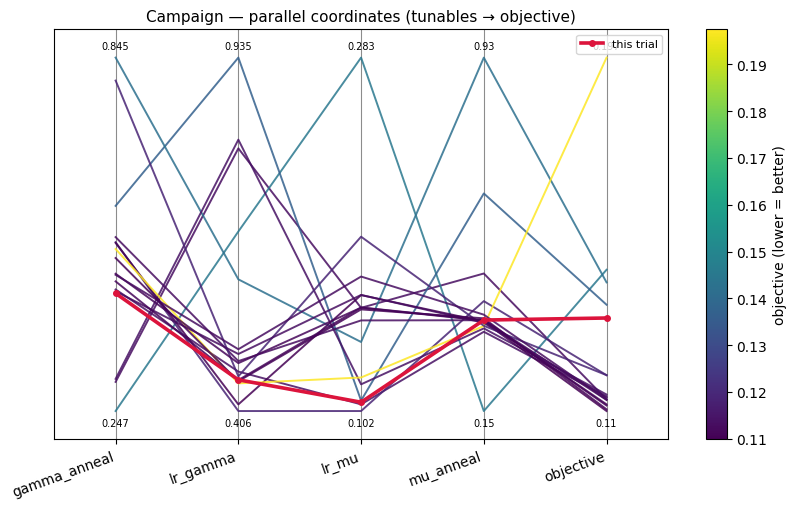

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 17 ran the highest-EI candidate (candidate 5, ei=3.93): `lr_mu=0.1067`, `mu_anneal=0.3508` (effective mu travel 0.088), `lr_gamma=0.4525`, `gamma_anneal=0.4465`. It completed in 7.7 min with objective **0.1329 +/- 0.0915** and **1 diverged cell** (1nW T05: gamma -0.93). Ranking: trial_08 0.1099 < ... < trial_06 = trial_11 0.1188 < **trial_17 0.1329** < trial_03 0.1362 < trial_04 0.1418 < trial_02 0.1449 < trial_10 0.1975.

Aggregate accuracy: **mu rel-RMSE 53.8%** (RMSE 29.04, bias -9.89) — the *best* mu of the campaign, in fact; **gamma rel-RMSE 42.5%** (RMSE 3.86, bias -2.34), inflated by the diverged cell.

Per-cell relative errors (1nW T05 gamma is the diverged value):
- **mu:** 1nW T05 +11.1%, T20 +108.5%, T60 -9.8%, T100 -11.8% | 3nW T05 +90.1%, T20 +19.3%, T60 -30.6%, T100 -40.6%.
- **gamma:** 1nW T05 **diverged (-0.93)**, T20 -29.7%, T60 -10.7%, T100 -3.0% | 3nW T05 -32.4%, T20 -10.1%, T60 +2.0%, T100 +0.5%.

The surrogate pointed at the low-travel region and the outcome repeated the hazard of that region: mu came out the most accurate of any trial (rel-RMSE 53.8%, mid-T overshoots the smallest yet, 3nW T20 +19.3%), but the fragile 1nW T05 gamma cell diverged again, and that single capped, weighted cell pushed the objective up to 0.1329. Crucially, the gamma schedule here (`lr_gamma=0.4525`, `gamma_anneal=0.4465`) is essentially the same as several safe runs (e.g. trial_16's `0.4520`/`0.4667`), so the divergence is not explained by the gamma knobs — it is a sporadic failure of the low-travel regime at the smallest-n_target cell. This is consistent with the earlier divergences (trials 03/04 at travel 0.074) and confirms that the optimum at travel ~0.13 is both better *and* more reliable than the low-travel region.

**Summary:** Trial 17 (lr_mu=0.1067, mu_anneal=0.3508, lr_gamma=0.4525, gamma_anneal=0.4465): objective 0.1329 +/- 0.0915 with 1 diverged cell (1nW T05, gamma -0.93); the high-EI low-travel pick (travel 0.088) still diverged at the fragile 1nW T05 cell despite a proven-safe gamma schedule, so the low-travel region is not reliably safe.
**Key insight:** The low-travel region (~0.088) again produced a 1nW T05 gamma divergence even with `lr_gamma=0.453`, matching the schedule of safe runs - so that divergence is the persistent hazard of small travel, and the optimum (travel ~0.13) remains both better and safer.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** This run is informative: it had the best mu accuracy of the campaign yet still scored 0.1329 because of one diverged low-count gamma cell, which is exactly the kind of failure a structural safeguard (per-experiment gamma LR / n_target-adaptive step, or a divergence-aware guard) would address. It also shows the objective is dominated by stability, not by mu accuracy per se. Recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 17 (lr_mu=0.1067, mu_anneal=0.3508, lr_gamma=0.4525, gamma_anneal=0.4465): objective 0.1329 +/- 0.0915 with 1 diverged cell (1nW T05, gamma -0.93); the high-EI low-travel pick (travel 0.088) still diverged at the fragile 1nW T05 cell despite a proven-safe gamma schedule, so the low-travel region is not reliably safe"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "The low-travel region (~0.088) again produced a 1nW T05 gamma divergence even with lr_gamma=0.453, matching the schedule of safe runs - so that divergence is the persistent hazard of small travel, and the optimum (travel ~0.13) remains both better and safer"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_17 | current best: trial_08


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_18.ipynb. Open it and follow its cells from the top.
